In [22]:
# imports
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# PT3 imports
from distfit import distfit  # fits statistical distributions to data
from scipy.stats import (
    pearson3,
    norm,
    randint,
    uniform,
)  # PT3 distribution and normal distribution tools

# sci-kit learn imports
from sklearn.linear_model import ElasticNet, SGDRegressor  # the model we're training
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
)  # cross-validated hyperparameter search
from sklearn.metrics import mean_squared_error  # computes MSE
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

# pytorch imports
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# for data transfer
import pickle

# shap
import shap
shap.initjs()

In [16]:
# load data

with open('../data/processed/kmeans.pkl', 'rb') as f:
    data = pickle.load(f)

X_train_clustered = data['X_train_clustered']
X_train_scaled = data['X_train_scaled'].drop(columns=['Cluster'], errors='ignore')
X_test_scaled = data['X_test_scaled']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
k_means_labels = data['K_means_labels']
k_means_model = data['K_means_model']


In [3]:
# show data

X_train_scaled.head()

,HSBASHHD,HSFD001S,HSHO001S,HSHF001S,HSTR001S,HSHC001S,HSPC001S,HSRE001S,HSRO001S,HSTA018S,...,ECYGEN1GEN,ECYGEN2GEN,ECYGEN3GEN,ECYTCAHPOP,ECYTCACIT,ECYTCA_U18,ECYTCA_18P,ECYNCANCIT,ECYNCA_U18,ECYNCA_18P
0,2.096885,1.924531,1.521558,1.919040,1.829394,2.207040,1.950844,2.051773,0.913626,1.965526,...,-0.228224,-0.121147,4.314653,1.727888,2.247607,2.242034,2.181706,-0.248492,-0.197283,-0.255273
1,-0.332897,-0.416294,-0.376221,-0.305056,0.000908,-0.388333,-0.318336,-0.293081,-0.566061,-0.265945,...,-0.520022,-0.405742,0.054563,-0.397312,-0.345664,-0.138669,-0.404826,-0.415133,-0.352709,-0.421172
2,-0.368225,-0.380159,-0.381707,-0.348902,-0.490942,-0.514085,-0.318584,-0.254495,0.029062,-0.317163,...,-0.375272,-0.179227,-0.136139,-0.336145,-0.329678,-0.200775,-0.363070,-0.248492,-0.274996,-0.237498
3,0.511050,0.525045,0.682765,0.458800,0.522289,0.285856,0.419810,0.668126,-0.139953,0.733696,...,-0.078878,-0.051450,1.383013,0.547221,0.645463,0.875717,0.548595,0.104396,0.139473,0.094301
4,0.063562,-0.177893,-0.182823,-0.271947,-0.167056,-0.100117,-0.179068,-0.200501,-0.232490,-0.145046,...,-0.225926,-0.173419,0.006080,-0.179671,-0.203567,-0.359488,-0.145013,-0.057345,-0.171379,-0.030124


In [4]:
# ============================================================
# STEP 3a-i â€” Fit PT3 distribution and transform y â†’ z_normal
# ============================================================

# --- Fit PT3 to y_train ---

# distfit tries many distributions; we restrict it to just 'pearson3'
# so it finds the best-fitting PT3 parameters on the training set only.
dfit = distfit(distr='pearson3')
dfit.fit_transform(y_train.values if hasattr(y_train, 'values') else y_train)

# Extract the three PT3 parameters: skewness (skew), location (loc), scale (scale).
# These describe the shape of your data's distribution.
pt3_params = dfit.model['params']   # returns (skew, loc, scale)
skew, loc, scale = pt3_params

print(f"PT3 params â€” skew: {skew:.4f}, loc: {loc:.4f}, scale: {scale:.4f}")


# --- Helper: transform y â†’ z_normal ---

def transform_to_znormal(y, skew, loc, scale, eps=1e-6):
    """
    Converts raw y values into z_normal:
      1. Evaluate the PT3 CDF at each y value â†’ gives a probability in [0,1].
      2. Clip away from 0 and 1 to prevent the next step returning Â±infinity.
      3. Apply the inverse standard-normal CDF (PPF) â†’ gives z values ~ N(0,1).
    """
    y_arr = np.array(y)

    # Step 1: PT3 CDF â€” "what percentile is each value?"
    cdf_vals = pearson3.cdf(y_arr, skew, loc=loc, scale=scale)

    # Step 2: Clip to (eps, 1-eps) so norm.ppf never hits -inf or +inf
    cdf_vals = np.clip(cdf_vals, eps, 1 - eps)

    # Step 3: Normal PPF â€” "what z-score corresponds to this percentile?"
    z = norm.ppf(cdf_vals)
    return z


# --- Transform training and test targets ---

# We fit PT3 only on y_train; we apply the same parameters to y_test
# (no "peeking" at the test distribution).
z_train = transform_to_znormal(y_train, skew, loc, scale)
z_test  = transform_to_znormal(y_test,  skew, loc, scale)

print(f"z_train â€” mean: {z_train.mean():.3f}, std: {z_train.std():.3f}")

[10-04-2026 17:11:43] [distfit.distfit] [INFO] fit
[10-04-2026 17:11:43] [distfit.distfit] [INFO] transform
[10-04-2026 17:11:44] [distfit.distfit] [INFO] [pearson3] [0.79 sec] [RSS: 18.8303] [loc=0.257 scale=0.049]
[10-04-2026 17:11:44] [distfit.distfit] [INFO] [pearson3] [0.79 sec] [RSS: 18.8303] [loc=0.257 scale=0.049]
[10-04-2026 17:11:44] [distfit.distfit] [INFO] Compute confidence intervals [parametric]


PT3 params â€” skew: 0.9501, loc: 0.2570, scale: 0.0489
z_train â€” mean: -0.004, std: 0.984


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

class ElasticNetModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x)

alphas    = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
l1_ratios = [0, 0.25, 0.5, 0.75, 1.0]

X_train_np = X_train_scaled.values  # numpy array for KFold indexing

# Move all training data to GPU once before the loops
X_train_gpu = torch.tensor(X_train_np, dtype=torch.float32).to(device)
z_train_gpu = torch.tensor(z_train,    dtype=torch.float32).to(device)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_r2, best_params = -np.inf, None

for l1 in tqdm(l1_ratios, desc="l1_ratio"):
    for alpha in alphas:
        fold_r2s = []
        for train_idx, val_idx in kf.split(X_train_np):
            train_idx_t = torch.tensor(train_idx, dtype=torch.long).to(device)
            val_idx_t   = torch.tensor(val_idx,   dtype=torch.long).to(device)

            Xf_tr_t  = X_train_gpu[train_idx_t]
            zf_tr_t  = z_train_gpu[train_idx_t].view(-1, 1)
            Xf_val_t = X_train_gpu[val_idx_t]
            zf_val   = z_train[val_idx]   # keep on CPU for r2_score

            model = ElasticNetModel(Xf_tr_t.shape[1]).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
            n = Xf_tr_t.shape[0]
            for _ in range(500):
                optimizer.zero_grad()
                preds = model(Xf_tr_t)
                l1_pen = sum(p.abs().sum() for p in model.parameters())
                l2_pen = sum((p**2).sum() for p in model.parameters())
                n = Xf_tr_t.shape[0]
                mse = torch.sum((preds - zf_tr_t) ** 2) / (2 * n)
                loss = mse + alpha * l1 * l1_pen + (alpha / 2) * (1 - l1) * l2_pen
                loss.backward()
                optimizer.step()
            with torch.no_grad():
                val_preds = model(Xf_val_t).cpu().numpy().flatten()
            fold_r2s.append(r2_score(zf_val, val_preds))
        mean_r2 = np.mean(fold_r2s)
        tqdm.write(f"  l1={l1}, alpha={alpha:.4f} → CV R²={mean_r2:.4f}  (best so far: {best_r2:.4f})")
        if mean_r2 > best_r2:
            best_r2, best_params = mean_r2, {"alpha": alpha, "l1_ratio": l1}

print("Best params:", best_params)


l1_ratio:   0%|          | 0/5 [00:07<?, ?it/s]

  l1=0.1, alpha=0.0001 → CV R²=0.7307  (best so far: -inf)


l1_ratio:   0%|          | 0/5 [00:13<?, ?it/s]

  l1=0.1, alpha=0.0010 → CV R²=0.7344  (best so far: 0.7307)


l1_ratio:   0%|          | 0/5 [00:18<?, ?it/s]

  l1=0.1, alpha=0.0100 → CV R²=0.7326  (best so far: 0.7344)


l1_ratio:   0%|          | 0/5 [00:23<?, ?it/s]

  l1=0.1, alpha=0.1000 → CV R²=0.6858  (best so far: 0.7344)


l1_ratio:  20%|██        | 1/5 [00:29<01:56, 29.19s/it]

  l1=0.1, alpha=1.0000 → CV R²=0.5006  (best so far: 0.7344)


l1_ratio:  20%|██        | 1/5 [00:34<01:56, 29.19s/it]

  l1=0.25, alpha=0.0001 → CV R²=0.7308  (best so far: 0.7344)


l1_ratio:  20%|██        | 1/5 [00:40<01:56, 29.19s/it]

  l1=0.25, alpha=0.0010 → CV R²=0.7334  (best so far: 0.7344)


l1_ratio:  20%|██        | 1/5 [00:46<01:56, 29.19s/it]

  l1=0.25, alpha=0.0100 → CV R²=0.7248  (best so far: 0.7344)


l1_ratio:  20%|██        | 1/5 [00:51<01:56, 29.19s/it]

  l1=0.25, alpha=0.1000 → CV R²=0.6501  (best so far: 0.7344)


l1_ratio:  40%|████      | 2/5 [00:57<01:26, 28.67s/it]

  l1=0.25, alpha=1.0000 → CV R²=0.2712  (best so far: 0.7344)


l1_ratio:  40%|████      | 2/5 [01:02<01:26, 28.67s/it]

  l1=0.5, alpha=0.0001 → CV R²=0.7341  (best so far: 0.7344)


l1_ratio:  40%|████      | 2/5 [01:08<01:26, 28.67s/it]

  l1=0.5, alpha=0.0010 → CV R²=0.7342  (best so far: 0.7344)


l1_ratio:  40%|████      | 2/5 [01:12<01:26, 28.67s/it]

  l1=0.5, alpha=0.0100 → CV R²=0.7128  (best so far: 0.7344)


l1_ratio:  40%|████      | 2/5 [01:17<01:26, 28.67s/it]

  l1=0.5, alpha=0.1000 → CV R²=0.6063  (best so far: 0.7344)


l1_ratio:  60%|██████    | 3/5 [01:21<00:52, 26.43s/it]

  l1=0.5, alpha=1.0000 → CV R²=0.0270  (best so far: 0.7344)


l1_ratio:  60%|██████    | 3/5 [01:24<00:52, 26.43s/it]

  l1=0.75, alpha=0.0001 → CV R²=0.7300  (best so far: 0.7344)


l1_ratio:  60%|██████    | 3/5 [01:28<00:52, 26.43s/it]

  l1=0.75, alpha=0.0010 → CV R²=0.7336  (best so far: 0.7344)


l1_ratio:  60%|██████    | 3/5 [01:32<00:52, 26.43s/it]

  l1=0.75, alpha=0.0100 → CV R²=0.7041  (best so far: 0.7344)


l1_ratio:  60%|██████    | 3/5 [01:37<00:52, 26.43s/it]

  l1=0.75, alpha=0.1000 → CV R²=0.5733  (best so far: 0.7344)


l1_ratio:  80%|████████  | 4/5 [01:41<00:23, 23.93s/it]

  l1=0.75, alpha=1.0000 → CV R²=0.0162  (best so far: 0.7344)


l1_ratio:  80%|████████  | 4/5 [01:45<00:23, 23.93s/it]

  l1=1.0, alpha=0.0001 → CV R²=0.7329  (best so far: 0.7344)


l1_ratio:  80%|████████  | 4/5 [01:49<00:23, 23.93s/it]

  l1=1.0, alpha=0.0010 → CV R²=0.7337  (best so far: 0.7344)


l1_ratio:  80%|████████  | 4/5 [01:53<00:23, 23.93s/it]

  l1=1.0, alpha=0.0100 → CV R²=0.6945  (best so far: 0.7344)


l1_ratio:  80%|████████  | 4/5 [01:56<00:23, 23.93s/it]

  l1=1.0, alpha=0.1000 → CV R²=0.5446  (best so far: 0.7344)


l1_ratio: 100%|██████████| 5/5 [02:00<00:00, 24.17s/it]

  l1=1.0, alpha=1.0000 → CV R²=0.0115  (best so far: 0.7344)
Best params: {'alpha': 0.001, 'l1_ratio': 0.1}


In [ ]:
# # train elasticnet model with best parameters

best_model = ElasticNet(
    alpha=best_params["alpha"],
    l1_ratio=best_params["l1_ratio"],
    max_iter=50000,
    random_state=42,
    tol=1e-4,
)

best_model.fit(X_train_np, z_train)

c:\Users\justi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.652e+03, tolerance: 4.403e+00
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [ ]:
# save the model and parameters
# with open('../data/processed/elasticnet_model.pkl', 'wb') as f:
#     pickle.dump({'best_model': best_model, 'best_params': best_params}, f)

In [10]:
# load the model and parameters
with open('../data/processed/elasticnet_model.pkl', 'rb') as f:
    saved = pickle.load(f)
    
best_model = saved['best_model']
best_params = saved['best_params']

In [11]:
# ============================================================
# STEP 3a-iv – Reverse-transform predictions back to y space
# ============================================================

# --- Helper: reverse z_normal → y ---

def inverse_transform(z_pred, skew, loc, scale, eps=1e-6):
    """
    Converts z_normal predictions back to the original y scale:
      1. Apply the normal CDF to z → gets back a probability in [0,1].
      2. Clip to avoid edge issues (mirroring what we did during forward transform).
      3. Apply the PT3 PPF (inverse CDF) → recovers the original y scale.
    """
    # Step 1: Normal CDF – "what percentile is each z-score?"
    p = norm.cdf(z_pred)

    # Step 2: Clip for numerical safety
    p = np.clip(p, eps, 1 - eps)

    # Step 3: PT3 PPF – "what y value sits at this percentile?"
    y_pred = pearson3.ppf(p, skew, loc=loc, scale=scale)
    return y_pred


# best_model is a sklearn ElasticNet — use .predict(), not a PyTorch forward pass.
z_pred_test  = best_model.predict(X_test_scaled.values)
z_pred_train = best_model.predict(X_train_np)
y_pred       = inverse_transform(z_pred_test,  skew, loc, scale)
y_pred_train = inverse_transform(z_pred_train, skew, loc, scale)


Test RÂ²:  0.4400
Test MSE: 0.0022

Bootstrapped 95% CI for RÂ²: [0.2589, 0.7177]
Bootstrap mean RÂ²:          0.4843


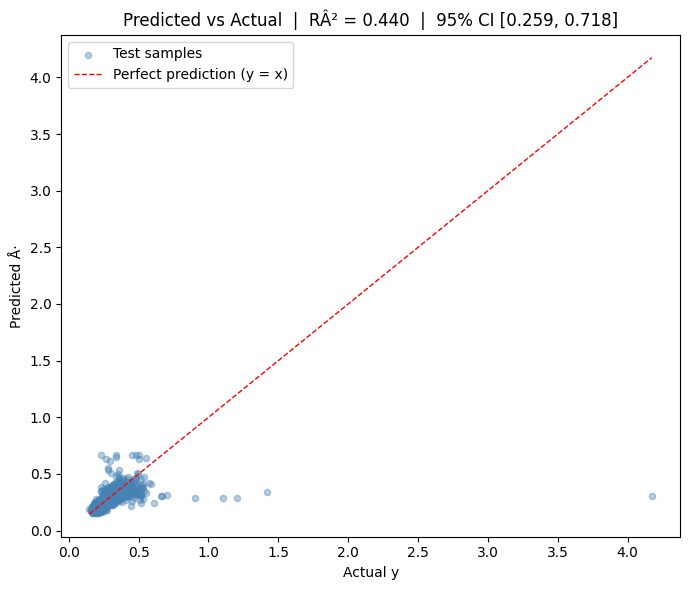


Scatterplot interpretation:
  - Points clustered tightly around the red dashed line â†’ good predictions.
  - Systematic curves (fan shape, banana) â†’ remaining non-linearity or
    heteroskedasticity not captured by the linear model.
  - A wide CI means the RÂ² estimate is unstable â€” possibly due to small test set.



In [12]:
# ============================================================
# STEP 3a-v â€” Report metrics and scatterplot
# ============================================================

# --- Point estimates ---

r2_test  = r2_score(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)

print(f"\nTest RÂ²:  {r2_test:.4f}")
print(f"Test MSE: {mse_test:.4f}")

# --- Bootstrapped 95% CI for RÂ² (1,000 iterations) ---

np.random.seed(42)
n_boot = 1_000                            # number of bootstrap resamples
boot_r2 = np.empty(n_boot)               # will store one RÂ² per resample

y_test_arr = np.array(y_test)            # make sure we can index by integer array
y_pred_arr = np.array(y_pred)

for i in range(n_boot):
    # Draw n indices with replacement from the test set.
    idx = np.random.randint(0, len(y_test_arr), size=len(y_test_arr))
    boot_r2[i] = r2_score(y_test_arr[idx], y_pred_arr[idx])

# The 2.5th and 97.5th percentiles of the bootstrap distribution form the 95% CI.
ci_low, ci_high = np.percentile(boot_r2, [2.5, 97.5])

print(f"\nBootstrapped 95% CI for RÂ²: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Bootstrap mean RÂ²:          {boot_r2.mean():.4f}")

# --- Scatterplot: predicted vs actual ---

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue', label='Test samples')

# Perfect-prediction reference line (y = x)
lims = [min(y_test_arr.min(), y_pred_arr.min()),
        max(y_test_arr.max(), y_pred_arr.max())]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction (y = x)')

ax.set_xlabel('Actual y')
ax.set_ylabel('Predicted Å·')
ax.set_title(
    f'Predicted vs Actual  |  RÂ² = {r2_test:.3f}  |  95% CI [{ci_low:.3f}, {ci_high:.3f}]'
)
ax.legend()
plt.tight_layout()
plt.show()

# --- Interpretation notes (printed for reference) ---
print("""
Scatterplot interpretation:
  - Points clustered tightly around the red dashed line â†’ good predictions.
  - Systematic curves (fan shape, banana) â†’ remaining non-linearity or
    heteroskedasticity not captured by the linear model.
  - A wide CI means the RÂ² estimate is unstable â€” possibly due to small test set.
""")

Per-group R² (K-Means clusters on test set):
----------------------------------------
  Cluster 0  (n=10179)  R² = 0.4433
  Cluster 1  (n=1129)  R² = 0.6538
  Cluster 2  (n=  64)  R² = -2.5642
----------------------------------------
  Overall test R²:          0.4400


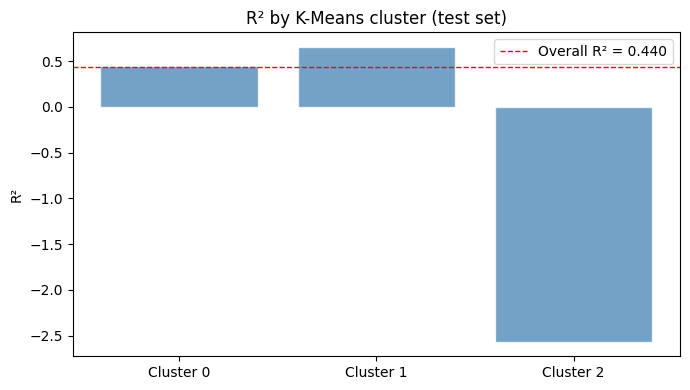

In [17]:
# ============================================================
# STEP 3a-vi – Per K-Means group R²
# ============================================================

kmeans_labels_test = k_means_model.predict(X_test_scaled.values)

unique_labels = sorted(set(kmeans_labels_test))
print("Per-group R² (K-Means clusters on test set):")
print("-" * 40)

group_r2 = {}

for label in unique_labels:
    mask = kmeans_labels_test == label
    r2_group = r2_score(y_test_arr[mask], y_pred_arr[mask])
    group_r2[label] = r2_group
    n_group = mask.sum()
    print(f"  Cluster {label}  (n={n_group:4d})  R² = {r2_group:.4f}")

print("-" * 40)
print(f"  Overall test R²:          {r2_test:.4f}")

# --- Quick bar chart ---
fig2, ax2 = plt.subplots(figsize=(7, 4))
labels_sorted = sorted(group_r2.keys())
r2_vals = [group_r2[k] for k in labels_sorted]

ax2.bar([f"Cluster {k}" for k in labels_sorted], r2_vals,
        color="steelblue", alpha=0.75, edgecolor="white")
ax2.axhline(r2_test, color="red", linestyle="--", linewidth=1, label=f"Overall R² = {r2_test:.3f}")
ax2.set_ylabel("R²")
ax2.set_title("R² by K-Means cluster (test set)")
ax2.legend()
plt.tight_layout()
plt.show()

Total features:            1124
Non-zero coefficients:     811
Zeroed-out (L1 excluded):  313

Top 5 coefficients by magnitude:
---------------------------------------------
  ECYPNIAVG                      -0.5305  (negative)
  HSHF004                        -0.3943  (negative)
  HSTA016                        +0.3637  (positive)
  HSOI040                        +0.3613  (positive)
  HSHE008                        +0.3104  (positive)
---------------------------------------------


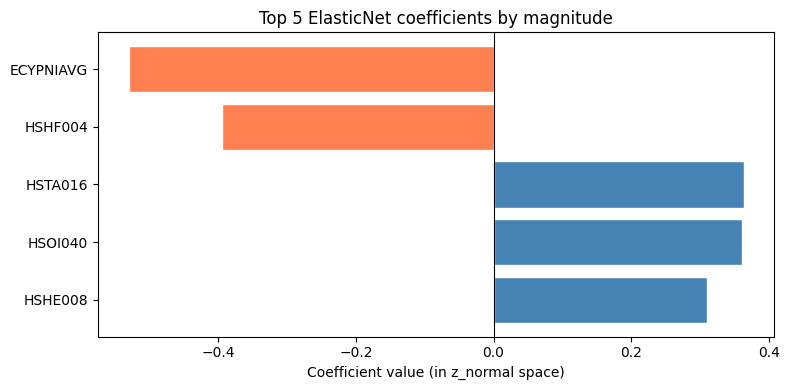


All non-zero coefficients (sorted by magnitude):
ECYPNIAVG     -0.530546
HSHF004       -0.394306
HSTA016        0.363670
HSOI040        0.361279
HSHE008        0.310363
HSFD992       -0.290287
HSRE067       -0.285890
HSCS004       -0.279433
HSTA020       -0.279232
HSRE110        0.276331
ECYHNI_020     0.275702
ECYHSZ4PER     0.271876
HSCL020        0.257970
HSRV007        0.257605
HSOI040Z      -0.254178
HSRE112       -0.252622
HSTA002       -0.246771
HSFD003       -0.245374
HSFD991       -0.243030
HSRV013       -0.243002
ECYMTNAVG     -0.242176
HSFD001       -0.241982
HSTR031        0.239725
ECYHRIAGG      0.239370
HSTA009        0.228349
HSPC023        0.225041
HSHC025        0.224176
HSTA015        0.220079
HSFD990       -0.217910
HSTR033       -0.216821
ECYCHAFHCH     0.204758
ECYHSZ5PER     0.203810
HSCL030S      -0.203216
HSCL015        0.203147
HSCS005        0.202146
HSPC008       -0.197221
ECYHNIAGG      0.195421
HSCL029       -0.193343
ECYBASCF       0.193122
HSED007       

In [19]:
# ============================================================
# STEP 3a-vii – Non-zero coefficients and top 5 by magnitude
# ============================================================

# Retrieve the coefficients from the best ElasticNet model.
# Each coefficient corresponds to one input feature, telling us
# how much a one-unit change in that feature shifts z_normal (our transformed target).
weights = best_model.coef_           # shape (n_features,)
bias    = best_model.intercept_   # scalar

feature_names = X_train_scaled.columns.tolist()
coef_series = pd.Series(weights, index=feature_names)

# --- Non-zero coefficients ---
# ElasticNet's L1 penalty drives less useful coefficients exactly to zero.
# The ones that survive (non-zero) are the features the model found meaningful.
nonzero_coefs = coef_series[coef_series.abs() > 1e-4]
print(f"Total features:            {len(coef_series)}")
print(f"Non-zero coefficients:     {len(nonzero_coefs)}")
print(f"Zeroed-out (L1 excluded):  {len(coef_series) - len(nonzero_coefs)}")

# --- Top 5 by magnitude ---
# We sort by absolute value because a large negative coefficient is just as
# influential as a large positive one - both indicate strong relationships.
top5 = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(5)

print("\nTop 5 coefficients by magnitude:")
print("-" * 45)
for feat, val in top5.items():
    direction = "positive" if val > 0 else "negative"
    print(f"  {feat:<30} {val:+.4f}  ({direction})")
print("-" * 45)

# --- Bar chart of top 5 ---
fig, ax = plt.subplots(figsize=(8, 4))

colors = ['steelblue' if v > 0 else 'coral' for v in top5.values]
ax.barh(top5.index[::-1], top5.values[::-1], color=colors[::-1], edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient value (in z_normal space)')
ax.set_title('Top 5 ElasticNet coefficients by magnitude')
plt.tight_layout()
plt.show()

# --- All non-zero coefficients for reference ---
print("\nAll non-zero coefficients (sorted by magnitude):")
print(coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)
      [coef_series.abs() > 1e-4].to_string())

In [23]:
# ----------------------------
# 2. DEFINE MODEL
# ----------------------------

xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    device='cuda',
    verbosity=1
)

# ----------------------------
# 3. HYPERPARAMETER SPACE
# ----------------------------

param_dist = {
    'n_estimators': randint(100, 600),        # keep moderate
    'max_depth': randint(3, 10),              # avoid very deep trees
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),           # 0.6 → 1.0
    'colsample_bytree': uniform(0.6, 0.4)
}

In [24]:
# ----------------------------
# 4. RANDOM SEARCH CV
# ----------------------------

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,                 # keep small for large dataset
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1                   # limit parallel CV jobs
)

# Fit model
random_search.fit(X_train_scaled, y_train)

# Best model
best_model = random_search.best_estimator_

print("Best Hyperparameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\justi\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Hyperparameters:
{'colsample_bytree': 0.6624074561769746, 'learning_rate': 0.041198904067240534, 'max_depth': 5, 'n_estimators': 558, 'subsample': 0.9464704583099741}


In [29]:
# save the model and parameters
with open('../data/processed/xgb_model.pkl', 'wb') as f:
    pickle.dump({'best_model': best_model, 'best_params': random_search.best_params_}, f)

c:\Users\justi\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:751: UserWarning: [19:11:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Test R2: 0.8010
Test MSE: 0.0008
95% CI for R2: [0.6945, 0.9413]


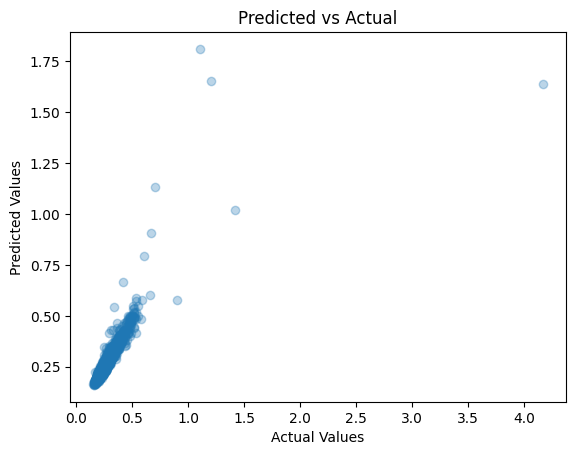

In [25]:
# ----------------------------
# 5. TEST PERFORMANCE
# ----------------------------

y_pred = best_model.predict(X_test_scaled)

y_test_np = y_test.to_numpy()
y_pred_np = np.array(y_pred)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Test R2: {r2:.4f}")
print(f"Test MSE: {mse:.4f}")

# ----------------------------
# 6. BOOTSTRAP 95% CI FOR R2
# ----------------------------

n_bootstrap = 1000
n_samples = len(y_test)

r2_scores = []

# Use indices instead of copying arrays (memory efficient)
rng = np.random.default_rng(42)

for _ in range(n_bootstrap):
    indices = rng.integers(0, n_samples, n_samples)
    
    r2_boot = r2_score(y_test_np[indices], y_pred_np[indices])
    r2_scores.append(r2_boot)

lower = np.percentile(r2_scores, 2.5)
upper = np.percentile(r2_scores, 97.5)

print(f"95% CI for R2: [{lower:.4f}, {upper:.4f}]")

# ----------------------------
# 7. SCATTER PLOT
# ----------------------------

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual")
plt.show()

In [26]:
# Create SHAP explainer (TreeExplainer is optimized for XGBoost)
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test_scaled)

# Optional: check shape
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (11372, 1124)


Top 10 features by mean |SHAP|: HSRV003B      0.014014
ECYHRIAVG     0.008241
ECYPNIAVG     0.004596
HSHE012C      0.004394
HSWH040S      0.003984
ECYHNIAVG     0.003019
ECYMTNAVG     0.002138
HSTR038       0.002073
HSRE067       0.002071
ECYHRI_020    0.001989
dtype: float32


C:\Users\justi\AppData\Local\Temp\ipykernel_27216\3721284312.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled, plot_type="dot")


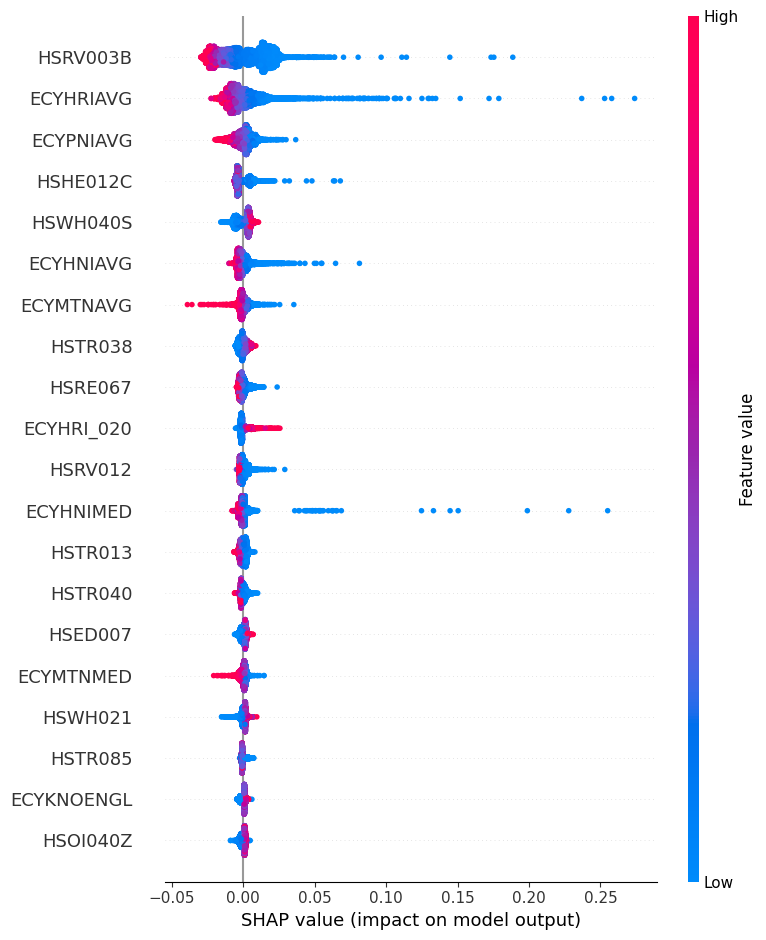

In [27]:
# Convert to DataFrame for easier handling
shap_df = pd.DataFrame(shap_values, columns=X_test_scaled.columns)

# Compute mean absolute SHAP values
mean_abs_shap = np.abs(shap_df).mean().sort_values(ascending=False)

# Top 10 features
top10_features = mean_abs_shap.head(10)
print("Top 10 features by mean |SHAP|:", top10_features)

# Beeswarm plot
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot")

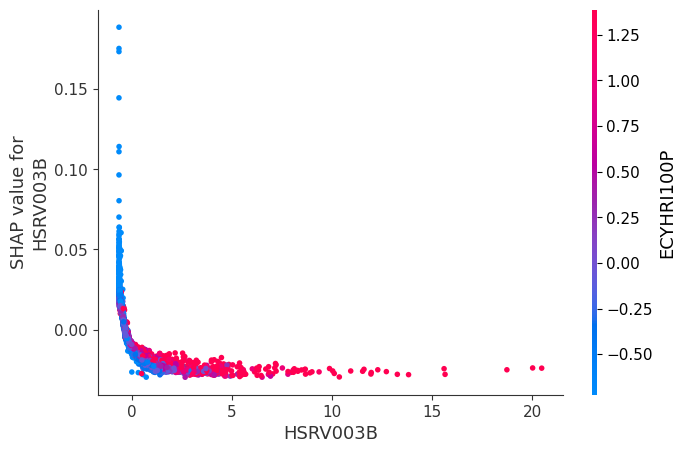

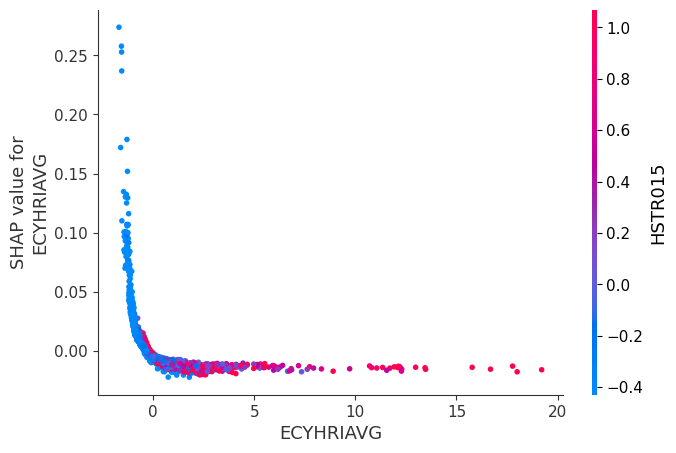

In [28]:
# Replace with actual top features of interest
feature_1 = top10_features.index[0]
feature_2 = top10_features.index[1]

# Dependence plots
shap.dependence_plot(feature_1, shap_values, X_test_scaled)
shap.dependence_plot(feature_2, shap_values, X_test_scaled)